In [1]:
from quapack.pyRPE import RobustPhaseEstimation
from quapack.pyRPE.quantum import Q
import numpy as np
import time
import os
import pygsti
import math
%matplotlib inline
import matplotlib.pyplot as plt
import scipy.optimize as opt
from pygsti.modelpacks import smq1Q_XY

from jaqalpaq import run
from jaqalpaq import emulator
from jaqalpaq.run import run_jaqal_file, run_jaqal_string, run_jaqal_batch, run_jaqal_circuit, frontend

from jaqalpaq.emulator.unitary import UnitarySerializedEmulator
emulator_backend = UnitarySerializedEmulator()
from qscout.v1.std.noisy import SNLToy1

from jaqalpaq.qsyntax import circuit
from jaqalpaq.generator import generate_jaqal_program

In [2]:
import jaqalpaq.core.block
jaqalpaq.core.block.DEFAULT_NUM_REPEATS = 1
import jaqalpaq.ipc.client
from jaqalpaq.generator import generate_jaqal_program
from jaqalpaq.core.algorithm.walkers import walk_circuit, discover_subcircuits
from jaqalpaq.core.algorithm import expand_subcircuits


import json
def special_emit(circuit, overrides, a=[0]):
    """(internal) Generate Jaqal appropriate for running on the hardware."""
    jaqal = generate_jaqal_program(circuit)
    overrides = overrides or {}
    try:
        overrides["__index__"]
    except KeyError:
        starts = [start for (start, end) in discover_subcircuits(circuit)]
        overrides["__index__"] = [list(walk_circuit(circuit, starts))]
    jaqal = jaqal.replace("from qscout.v1.std usepulses *", "from Calibration_PulseDefinitions.SandboxPulses usepulses *")
    jaqal = "".join((jaqal, "\n// OVERRIDES: ", json.dumps(overrides), "\n"))

    print(a[0])
    a[0] += 1
    print(jaqal)
    return jaqal
jaqalpaq.ipc.client.emit_jaqal_for_hardware = special_emit

In [3]:
def make_cos_subcirc(Q,k,qubit):
    with Q.loop(k):
        Q.Sx(qubit)

def make_sin_subcirc(Q,k,qubit):
    with Q.loop(k+1):
        Q.Sx(qubit)

In [4]:
#def X_gate(theta):
#    H = theta/2 * pygsti.sigmax
#    U = scipy.linalg.expm(-1j * H)
#    return pygsti.unitary_to_pauligate(U)

In [5]:
#target_model = smq1Q_XY.target_model()

In [6]:
max_exp = 8

max_lengths = [2**i for i in range(max_exp+1)]

In [7]:

@circuit
def cos_circs(Q,lengths):
    Q.usepulses("qscout.v1.std")
    q = Q.register(1, name = 'q')
    for k in lengths:
        with Q.subcircuit():
            make_cos_subcirc(Q,k,q[0])
    return(Q)

def cos_circs_labels(lengths):
    labels = []
    for k in max_lengths:
        labels.append("(Sx q[0])^%i"%k)
    return labels

@circuit
def sin_circs(Q,lengths):
    Q.usepulses("qscout.v1.std")
    q = Q.register(1, name = 'q')
    for k in lengths:
        with Q.subcircuit():
            make_sin_subcirc(Q,k,q[0])
    return(Q)

def sin_circs_labels(lengths):
    labels = []
    for k in max_lengths:
        labels.append("(Sx q[0])^%i"%(k+1))
    return labels

@circuit
def all_circs(Q,lengths):
    Q.usepulses("qscout.v1.std")
    q = Q.register(1, name = 'q')
    for k in lengths:
        with Q.subcircuit():
            make_cos_subcirc(Q,k,q[0])
    for k in lengths:
        with Q.subcircuit():
            make_sin_subcirc(Q,k,q[0])
    return(Q)


print(generate_jaqal_program(all_circs(max_lengths)))
print(sin_circs_labels(max_lengths))


all_circuits = all_circs(max_lengths)

#circuits = [make_cos_circ(k) for k in max_lengths]+[make_sin_circ(k) for k in max_lengths]

from qscout.v1.std usepulses *

register q[1]

subcircuit {
	loop 1 {
		Sx q[0]
	}
}
subcircuit {
	loop 2 {
		Sx q[0]
	}
}
subcircuit {
	loop 4 {
		Sx q[0]
	}
}
subcircuit {
	loop 8 {
		Sx q[0]
	}
}
subcircuit {
	loop 16 {
		Sx q[0]
	}
}
subcircuit {
	loop 32 {
		Sx q[0]
	}
}
subcircuit {
	loop 64 {
		Sx q[0]
	}
}
subcircuit {
	loop 128 {
		Sx q[0]
	}
}
subcircuit {
	loop 256 {
		Sx q[0]
	}
}
subcircuit {
	loop 2 {
		Sx q[0]
	}
}
subcircuit {
	loop 3 {
		Sx q[0]
	}
}
subcircuit {
	loop 5 {
		Sx q[0]
	}
}
subcircuit {
	loop 9 {
		Sx q[0]
	}
}
subcircuit {
	loop 17 {
		Sx q[0]
	}
}
subcircuit {
	loop 33 {
		Sx q[0]
	}
}
subcircuit {
	loop 65 {
		Sx q[0]
	}
}
subcircuit {
	loop 129 {
		Sx q[0]
	}
}
subcircuit {
	loop 257 {
		Sx q[0]
	}
}

['(Sx q[0])^2', '(Sx q[0])^3', '(Sx q[0])^5', '(Sx q[0])^9', '(Sx q[0])^17', '(Sx q[0])^33', '(Sx q[0])^65', '(Sx q[0])^129', '(Sx q[0])^257']


In [8]:
#pygsti.remove_duplicates_in_place(circuits)

In [9]:
#Here you would write to file the empty dataset
#pygsti.io.write_empty_dataset('empty_rpe_dataset_1Q_.txt',circuits)

In [10]:
target_theta_x = np.pi/2

In [11]:
#Define the rotation angles used for the simulated dataset
delta_theta_x = 0.05

theta_x = target_theta_x + delta_theta_x

#noisy_model = target_model.copy()
#noisy_model['Gxpi2',0] = X_gate(theta_x)

In [12]:
AMP_MIN      = 0.0
AMP_MAX      = 100.0
DEPOL        = 2e-4

USE_EMULATOR = True   # set False to run on hardware

In [13]:
def exp_rpe(amp, N):
    #Hardcode override for q[0]
    amp_list       = [0] * 16
    amp_list[2]    = amp
    nested_amp_list = [amp_list]

    #For emulator
    delta_theta = (np.pi / 80 * amp) - np.pi / 2
    backend = SNLToy1(1, rotation_error=delta_theta, depolarization=DEPOL)
    dataset = run.run_jaqal_circuit(all_circuits, backend=backend,
                                    overrides={'__repeats__': N})

    #For experiment
    #dataset = run.run_jaqal_circuit(expand_subcircuits(all_circuits), overrides = {'__repeats__': N, 'j.pd.amp1_coprop_list': nested_amp_list})

    probs = {}
    for ii in range(len(max_lengths)):
        probs[cos_circs_labels(max_lengths)[ii]] = dataset.subcircuits[ii].relative_frequency_by_int
        probs[sin_circs_labels(max_lengths)[ii]] = dataset.subcircuits[len(max_lengths)+ii].relative_frequency_by_int

    experiment = Q()
    for i, k in enumerate(max_lengths):
        sin_circ = sin_circs_labels(max_lengths)[i]
        cos_circ = cos_circs_labels(max_lengths)[i]
        experiment.process_sin(k, (int(probs[sin_circ][1]*N),
                                   int(probs[sin_circ][0]*N)))
        experiment.process_cos(k, (int(probs[cos_circ][0]*N),
                                   int(probs[cos_circ][1]*N)))

    analysis = RobustPhaseEstimation(experiment)
    last_good_estimate_generation = analysis.check_unif_local(historical=True)
    angle_estimate = analysis.angle_estimates[last_good_estimate_generation]
    return angle_estimate, last_good_estimate_generation

In [14]:
def bo_objective(u, N):
    """
    u[0] ∈ [-1, 1] → amp ∈ [0, 100]
    Returns (−|π/2 − θ_est|, σy) so that Julia maximizes ↔ minimizes angle error.
    σy is estimated from the RPE resolution at the last good generation.
    """
    u = list(u)  # PythonCall may pass a Py array
    amp = AMP_MIN + (u[0] + 1.0) / 2.0 * (AMP_MAX - AMP_MIN)

    theta_est, last_good_estimate_generation = exp_rpe(amp, N)
    error = abs(target_theta_x - theta_est)

    sigma = max(np.pi / (2**(last_good_estimate_generation + 1) * math.sqrt(N)), 1e-4)
    return -error, sigma

In [15]:
from juliacall import Main as jl
_repo_root = os.getcwd()
jl.seval(f'import Pkg; Pkg.activate("{_repo_root}"; io=devnull)')
jl.seval('Pkg.instantiate(; io=devnull)')
jl.seval(f'include("{os.path.join(_repo_root, "src", "bayes_hetero_opt.jl")}")')
print('Julia BO loaded.')

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


┌ Warning: The active manifest file has dependencies that were resolved with a different julia version (1.11.6). Unexpected behavior may occur.
└ @ ~/Library/CloudStorage/OneDrive-UW/PhD/1-Code/QuantumFidelityOptimization/Manifest.toml:0
┌ Warning: The project dependencies or compat requirements have changed since the manifest was last resolved.
│ It is recommended to `Pkg.resolve()` or consider `Pkg.update()` if necessary.
└ @ Pkg.API ~/.julia/juliaup/julia-1.12.6+0.aarch64.apple.darwin14/share/julia/stdlib/v1.12/Pkg/src/API.jl:1322
┌ Error: Error during loading of extension StructUtilsStaticArraysCoreExt of StructUtils, use `Base.retry_load_extensions()` to retry.
│   exception =
│    1-element ExceptionStack:
│    ArgumentError: Package StructUtilsStaticArraysCoreExt [5f8627f4-f0c5-5aac-996c-f7a3cc29134a] is required but does not seem to be installed:
│     - Run `Pkg.instantiate()` to install all recorded dependencies.
│    
│    Stacktrace:
│      [1] __require_prelocked(pkg::Base

Julia BO loaded.


In [16]:
N               = 200    # shots per RPE subcircuit (= __repeats__)
N_INIT          = 5      # random initial evaluations before GP is fitted
N_ITER          = 30     # max BO iterations
KAPPA           = 2.0    # UCB exploration weight
HYPER_EVERY     = 5      # re-optimise GP hyperparameters every N iterations
N_RESTARTS      = 5      # random restarts for hyperparameter optimisation
FIDELITY_THRESH = None   # stop when −error ≥ threshold, e.g. -0.01 (error < 0.01 rad)

# 1-D normalised bounds
bounds    = [(-1.0, 1.0)]
jl_bounds = jl.seval('Vector{Tuple{Float64,Float64}}')([tuple(b) for b in bounds])

In [17]:
jl.seval("""
function _run_bo(f, bounds, n_shots, n_init, n_iter, kap, seed_val,
                 hyper_every, n_restarts, fid_thresh)
    bayesopt_ucb_threshold(f;
        bounds=bounds,
        n_shots=n_shots,
        n_init=n_init,
        n_iter=n_iter,
        κ=kap,
        seed=seed_val,
        maximize=true,
        fidelity_threshold=fid_thresh,
        hyper_every=hyper_every,
        learn_noise_scale=true,
        n_restarts=n_restarts,
    )
end
""")

fid_julia = jl.nothing if FIDELITY_THRESH is None else float(FIDELITY_THRESH)

bo_start = time.time()
result = jl._run_bo(
    bo_objective,
    jl_bounds,
    N, N_INIT, N_ITER,
    float(KAPPA),
    42,
    HYPER_EVERY, N_RESTARTS,
    fid_julia,
)
bo_elapsed = time.time() - bo_start
print(f'BO completed in {bo_elapsed:.2f} s')

BO completed in 255.87 s


In [18]:
u_last   = list(result.X_opt[:, -1])  # last recommended point (normalised)
amp_last = AMP_MIN + (u_last[0] + 1.0) / 2.0 * (AMP_MAX - AMP_MIN)
err_last = -float(result.y_last_opt)

bo_amp_trace = [AMP_MIN + (u[0] + 1.0) / 2.0 * (AMP_MAX - AMP_MIN) for u in np.array(result.X_opt).T]

print(f'Recommended amp        = {amp_last:.4f}')
print(f'Angle error at x_last  = {err_last:.6f} rad')
print(f'GP mean angle error    = {-float(result.mu_opt[-1]):.6f} rad')
print(f'Iterations used        = {result.n_iter_actual}')
print(f'Total RPE calls        = {result.total_shots}'
      f'  (×{len(max_lengths)*2} subcircuits each = {result.total_shots * len(max_lengths) * 2 * N} shots)')
print(f'Acq evaluations        = {len(result.i_acq)}')
print(f'Opt evaluations        = {len(result.i_opt)}')

Recommended amp        = 39.9984
Angle error at x_last  = 0.000257 rad
GP mean angle error    = 0.000669 rad
Iterations used        = 30
Total RPE calls        = 7200  (×18 subcircuits each = 25920000 shots)
Acq evaluations        = 26
Opt evaluations        = 0


In [19]:
estimated_angles = []
input_amps       = []
last_lengths     = []

def calibrate_pi2(amp):
    amp = float(amp[0]) if hasattr(amp, '__len__') else float(amp)
    theta_est, last_good_estimate_generation = exp_rpe(amp, N)
    input_amps.append(amp)
    estimated_angles.append(theta_est)
    last_lengths.append(2**last_good_estimate_generation)
    return abs(target_theta_x - theta_est)

start = time.time()
opt.minimize(fun=calibrate_pi2, x0=[60.0], bounds=[(AMP_MIN, AMP_MAX)],
             tol=0.01, method='COBYLA', options={'maxiter': N_ITER})
COBYLA_estimated_angles = estimated_angles[:]
COBYLA_test_amps        = input_amps[:]
COBYLA_RPE_last_lengths = last_lengths[:]
elapsed = time.time() - start
print(f'COBYLA       {elapsed:.2f}s  {len(COBYLA_test_amps):3d} evals'
      f'  best error = {min(abs(target_theta_x - a) for a in COBYLA_estimated_angles):.6f} rad')

estimated_angles[:] = []; input_amps[:] = []; last_lengths[:] = []
start = time.time()
opt.minimize(fun=calibrate_pi2, x0=[60.0], bounds=[(AMP_MIN, AMP_MAX)],
             tol=0.01, method='Nelder-Mead', options={'maxiter': N_ITER})
NM_estimated_angles = estimated_angles[:]
NM_test_amps        = input_amps[:]
NM_RPE_last_lengths = last_lengths[:]
elapsed = time.time() - start
print(f'Nelder-Mead  {elapsed:.2f}s  {len(NM_test_amps):3d} evals'
      f'  best error = {min(abs(target_theta_x - a) for a in NM_estimated_angles):.6f} rad')

estimated_angles[:] = []; input_amps[:] = []; last_lengths[:] = []
start = time.time()
opt.minimize(fun=calibrate_pi2, x0=[60.0], bounds=[(AMP_MIN, AMP_MAX)],
             tol=0.01, method='Powell', options={'maxiter': N_ITER})
P_estimated_angles = estimated_angles[:]
P_test_amps        = input_amps[:]
P_RPE_last_lengths = last_lengths[:]
elapsed = time.time() - start
print(f'Powell       {elapsed:.2f}s  {len(P_test_amps):3d} evals'
      f'  best error = {min(abs(target_theta_x - a) for a in P_estimated_angles):.6f} rad')

COBYLA       2.00s   30 evals  best error = 0.000087 rad
Nelder-Mead  2.09s   30 evals  best error = 0.000125 rad
Powell       8.58s  127 evals  best error = 0.000000 rad


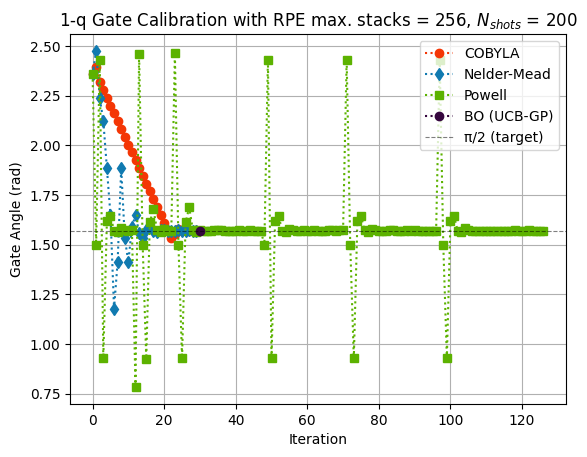

In [20]:
fig1 = plt.figure(1)
plt.clf()

plt.xlabel('Iteration')
plt.ylabel('Gate Angle (rad)')
plt.grid()
plt.title('1-q Gate Calibration with RPE max. stacks = %i, $N_{shots}$ = %i' % (2**max_exp, N))
plt.plot(range(len(COBYLA_estimated_angles)),  COBYLA_estimated_angles,  linestyle=':', marker='o', color='xkcd:orangish red',   label='COBYLA')
plt.plot(range(len(NM_estimated_angles)),      NM_estimated_angles,      linestyle=':', marker='d', color='xkcd:nice blue',      label='Nelder-Mead')
plt.plot(range(len(P_estimated_angles)),       P_estimated_angles,       linestyle=':', marker='s', color='xkcd:kermit green',   label='Powell')
plt.plot(result.n_iter_actual, result.y_last_opt + target_theta_x,           linestyle=':', marker='o', color='xkcd:dark purple',    label='BO (UCB-GP)')
plt.axhline(target_theta_x, color='k', linestyle='--', linewidth=0.8, alpha=0.5, label='π/2 (target)')
plt.legend()
plt.show()

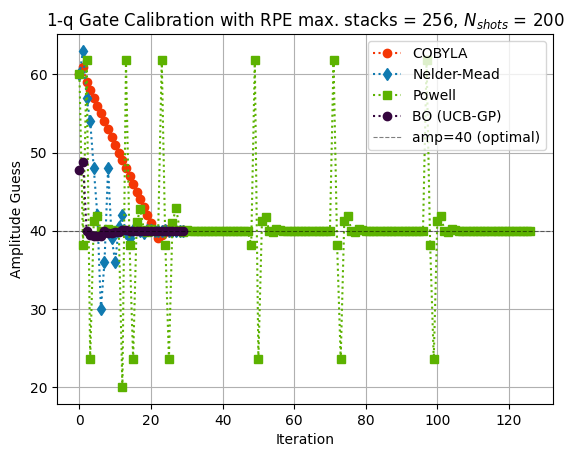

In [21]:
fig2 = plt.figure(2)
plt.clf()

plt.xlabel('Iteration')
plt.ylabel('Amplitude Guess')
plt.grid()
plt.title('1-q Gate Calibration with RPE max. stacks = %i, $N_{shots}$ = %i' % (2**max_exp, N))
plt.plot(range(len(COBYLA_test_amps)), COBYLA_test_amps, linestyle=':', marker='o', color='xkcd:orangish red', label='COBYLA')
plt.plot(range(len(NM_test_amps)),    NM_test_amps,    linestyle=':', marker='d', color='xkcd:nice blue',      label='Nelder-Mead')
plt.plot(range(len(P_test_amps)),     P_test_amps,     linestyle=':', marker='s', color='xkcd:kermit green',   label='Powell')
plt.plot(range(len(bo_amp_trace)),    bo_amp_trace,    linestyle=':', marker='o', color='xkcd:dark purple',    label='BO (UCB-GP)')
plt.axhline(40.0, color='k', linestyle='--', linewidth=0.8, alpha=0.5, label='amp=40 (optimal)')
plt.legend()
plt.show()

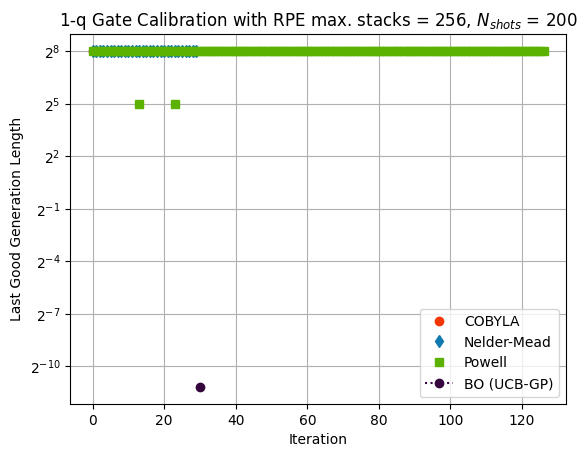

In [22]:
fig3 = plt.figure(3)
plt.clf()

plt.xlabel('Iteration')
plt.ylabel('Last Good Generation Length')
plt.yscale('log', base=2)
plt.grid()
plt.title('1-q Gate Calibration with RPE max. stacks = %i, $N_{shots}$ = %i' % (2**max_exp, N))
plt.plot(range(len(COBYLA_RPE_last_lengths)), COBYLA_RPE_last_lengths, linestyle='None', marker='o', color='xkcd:orangish red',   label='COBYLA')
plt.plot(range(len(NM_RPE_last_lengths)),     NM_RPE_last_lengths,     linestyle='None', marker='d', color='xkcd:nice blue',      label='Nelder-Mead')
plt.plot(range(len(P_RPE_last_lengths)),      P_RPE_last_lengths,      linestyle='None', marker='s', color='xkcd:kermit green',   label='Powell')
plt.plot(result.n_iter_actual, result.σy_opt,           linestyle=':', marker='o', color='xkcd:dark purple',    label='BO (UCB-GP)')
plt.legend()
plt.show()

In [ ]:
#For later!

#def qubit_mapping():
#    q0 = 2
#    q1 = 3
#    qn1 = 1
#    q2 = 6
#    qn2 = 7
#    q3 = 8
#    qn3 = 9 # Not connected yet.
#    monitor = 7
#    targets = [q0, q1, qn1, q2, qn2, q3, qn3]
#    return targets
#
#def nion_mask(nions):
#    nions=int(nions)
#    targets= qubit_mapping()
#    max_channels = 16
#    to_return = np.zeros((max_channels, ))
#    for i in range(nions):
#        to_return[targets[i]] = 1
#    # to_return[monitor] = 1
#    return to_return